In [40]:
# Stuff to import + seed generator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mp1lib import bsc


#Seed Generator
SEED = 1234 #we didn't have a group number so we are using 1234 as the seed
rng = np.random.default_rng(SEED)
rng_step = rng.spawn(1)[0]

Total simulated packets: 1,000,000
Total exact probability: 1.000000
Total simulated probability: 1.000000


,Error Pattern,# occurrences (sim),Prob (Calc),Prob (Sim),Difference (%)
0,0000,656206,0.6561,0.656206,1.615607e-02
1,0001,72926,0.0729,0.072926,3.566529e-02
2,0010,73018,0.0729,0.073018,1.618656e-01
3,0011,8132,0.0081,0.008132,3.950617e-01
4,0100,72571,0.0729,0.072571,-4.513032e-01
5,0101,8149,0.0081,0.008149,6.049383e-01
6,0110,7947,0.0081,0.007947,-1.888889e+00
7,0111,845,0.0009,0.000845,-6.111111e+00
8,1000,72917,0.0729,0.072917,2.331962e-02
9,1001,8147,0.0081,0.008147,5.802469e-01


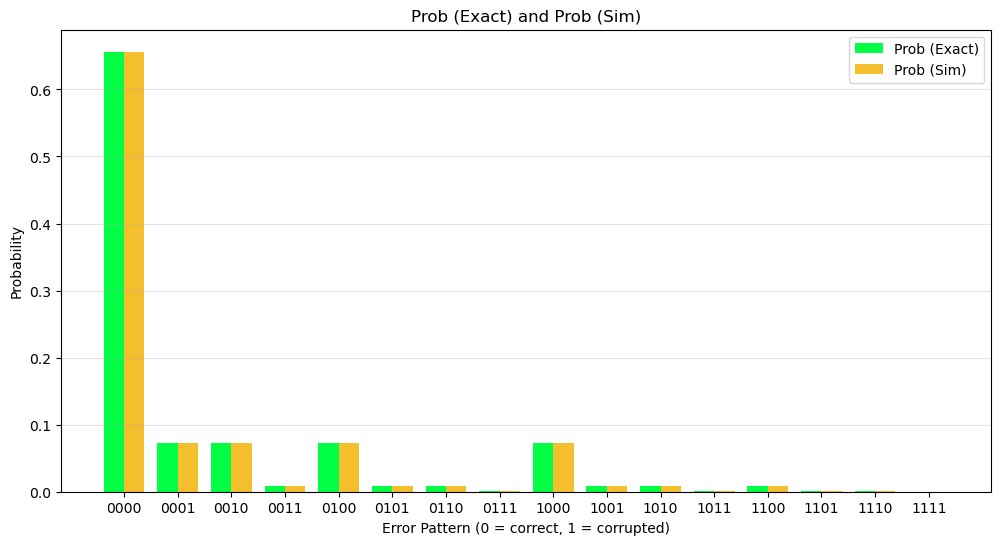

{'P(A)': np.float64(0.189718),
 'P(B)': np.float64(0.048736),
 'P(C)': np.float64(0.100085),
 'P(A and B)': np.float64(0.040604),
 'P(A and C)': np.float64(0.019027),
 'P(B and C)': np.float64(0.024428),
 'P(A and B and C)': np.float64(0.016296),
 'P(A or B or C)': np.float64(0.270776)}

In [41]:
#STEP 1 - THE SAMPLE SPACE AND THE AXIOMS

N = 10**6 #1 million 4-bit packets
p = 0.1 #error probability

bits = np.zeros((N, 4), dtype=int) #every packet starts with four correct bits

#bsc changes some 0s into 1s according to p value and the random number generator
packets = bsc(bits, p, rng_step) #bsc func in mp1lib.py

#count each simulated 4-bit error pattern.
pattern_numbers = packets @ np.array([8, 4, 2, 1])
counts = np.bincount(pattern_numbers, minlength=16)
patterns = [format(i, "04b") for i in range(16)]

#Calculated probability:(1-p)^(correct bits) * p^(corrupted bits) ex. (0.9)^4*(0.1)^0 = 0.6561 for 0000
number_of_errors = np.array([pattern.count("1") for pattern in patterns])
prob_exact = (1 - p) ** (4 - number_of_errors) * p ** number_of_errors
prob_sim = counts / N
percent_difference = (prob_sim - prob_exact) / prob_exact * 100


print(f"Total simulated packets: {counts.sum():,}") #total should be 1 million
print(f"Total exact probability: {prob_exact.sum():.6f}") #should add up to 1
print(f"Total simulated probability: {prob_sim.sum():.6f}") #should add up to 1

section1_table = pd.DataFrame({ #creates table data
    "Error Pattern": patterns,
    "# occurrences (sim)": counts,
    "Prob (Calc)": prob_exact,
    "Prob (Sim)": prob_sim,
    "Difference (%)": percent_difference,
})

display(section1_table) #prints table

x = np.arange(len(patterns)) #creates graph of all patterns and their probabilities
bar_width = 0.38
plt.figure(figsize=(12, 6))
plt.bar(x - bar_width / 2, prob_exact, bar_width, label="Prob (Exact)", color="#00ff44")
plt.bar(x + bar_width / 2, prob_sim, bar_width, label="Prob (Sim)", color="#f4bf2d")
plt.xticks(x, patterns)
plt.xlabel("Error Pattern (0 = correct, 1 = corrupted)")
plt.ylabel("Probability")
plt.title("Prob (Exact) and Prob (Sim)")
plt.grid(axis="y", alpha=0.35)
plt.legend()
plt.show()

A = np.any(packets[:, 0:2] == 1, axis=1) #prob. of an error in the first two bits
B = np.sum(packets, axis=1) == 2 #prob. of exactly two errors in the packet
C = packets[:, 3] == 1 #prob. of an error in the last bit


empirical = {
    "P(A)": np.mean(A), #expected output 0.19
    "P(B)": np.mean(B), #expected output 0.0486
    "P(C)": np.mean(C), #expected output 0.1
    "P(A and B)": np.mean(A & B),
    "P(A and C)": np.mean(A & C),
    "P(B and C)": np.mean(B & C),
    "P(A and B and C)": np.mean(A & B & C),
    "P(A or B or C)": np.mean(A | B | C), #expected output 0.2710
}

empirical

Bayes Rule P(error | flag) = P(flag | error)P(error) / P(flag)
P(F | E) = 0.95
P(F | not E) = 0.02
P(E) = p, P(not E) = 1 - p
P(F) = P(F | E) P(E) + P(F | not E) P(not E)
Bayes Rule P(E | F) = P(F | E) P(E) / P(F)
 = 0.95 * p + 0.02 * (1 - p) 


p = 0.1: posterior = 0.840708
p = 0.01: posterior = 0.324232
p = 0.001: posterior = 0.045389


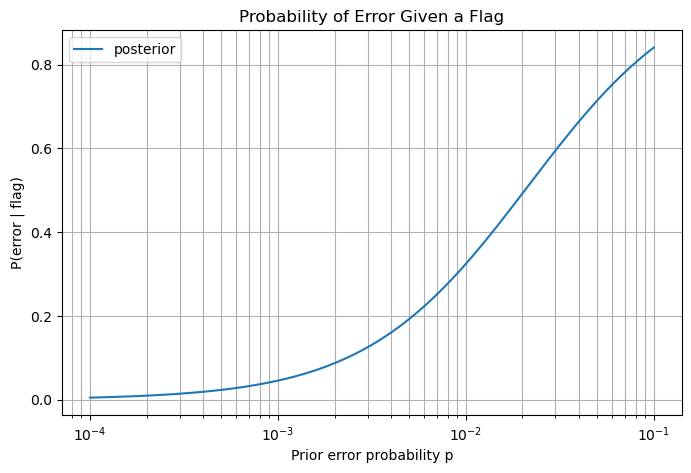

Crossover p = 0.020619
# flags: 391,066
# true errors flagged: 195,015
posterior: 0.500000
Monte Carlo estimate: 0.498675
Std error: 0.000800
Difference: 0.001325


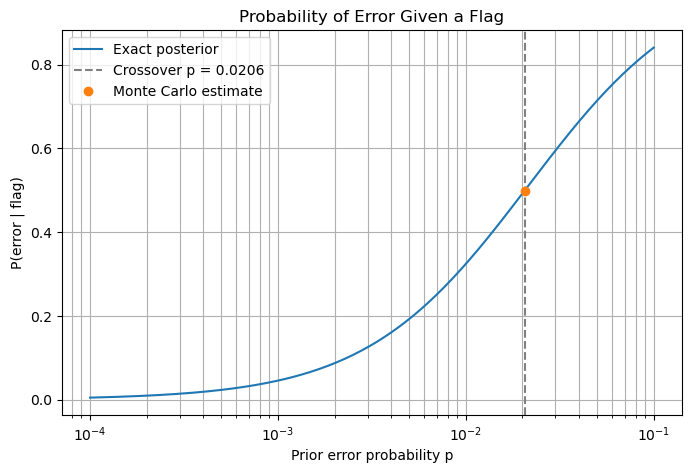

The reason why a 95% accurate circuit means nothing on a good link is because
the system will always flag a lot of bits as errors even when they're not supposed to be errors.
For example in our scenario, there were 391,066 flags, but only 195,015 were actually errors.
So there were an almost 200,000 extra flags that were false positives, which would need to be sorted out.


In [42]:
# STEP 2 - CONDITIONAL PROBABILITY AND BAYES

print(f"Bayes Rule P(error | flag) = P(flag | error)P(error) / P(flag)")
print(f"P(F | E) = 0.95")
print(f"P(F | not E) = 0.02")
print(f"P(E) = p, P(not E) = 1 - p")
print(f"P(F) = P(F | E) P(E) + P(F | not E) P(not E)")
print(f"Bayes Rule P(E | F) = P(F | E) P(E) / P(F)")
print(f" = 0.95 * p + 0.02 * (1 - p) \n\n")


def posterior(p):
    return (0.95 * p) / (0.95 * p + 0.02 * (1 - p))

for p in [0.1, 0.01, 0.001]: # prints the posterior for p = 0.1, 0.01, and 0.001
    print(f"p = {p}: posterior = {posterior(p):.6f}")

p_values = np.logspace(-4, -1, 200) #creates 200 p values from 10^-4 to 10^-1 (log curve)
posterior_values = posterior(p_values)

#plots log curve
plt.figure(figsize=(8, 5))
plt.plot(p_values, posterior_values, label="posterior")
plt.xscale("log")
plt.xlabel("Prior error probability p")
plt.ylabel("P(error | flag)")
plt.title("Probability of Error Given a Flag")
plt.grid(True, which="both")
plt.legend()
plt.show()

#finds point where posterior=0.5.
p_cross = 0.02 / (0.95 + 0.02)
print(f"Crossover p = {p_cross:.6f}")

#simulates 10 million bits at the crossover point
rng_step2 = rng.spawn(1)[0]
N = 10**7

#gives error status based on crossover prob
errors = rng_step2.random(N) < p_cross

# The circuit flags an error 95% of the time if it is wrong,
# and flags a correct bit 2% of the time.
flag_probability = np.where(errors, 0.95, 0.02)
flags = rng_step2.random(N) < flag_probability

# Count all flags and flags that were truly errors.
number_of_flags = np.sum(flags)
number_flagged_and_in_error = np.sum(flags & errors)

# Estimated posterior = flagged errors / all flags.
posterior_estimate = number_flagged_and_in_error / number_of_flags

# Calculate uncertainty in the simulation estimate.
standard_error = np.sqrt(
    posterior_estimate * (1 - posterior_estimate) / number_of_flags
)
exact_posterior = posterior(p_cross)
difference = abs(posterior_estimate - exact_posterior)

print(f"# flags: {number_of_flags:,}")
print(f"# true errors flagged: {number_flagged_and_in_error:,}")
print(f"posterior: {exact_posterior:.6f}")
print(f"Monte Carlo estimate: {posterior_estimate:.6f}")
print(f"Std error: {standard_error:.6f}")
print(f"Difference: {difference:.6f}")

#plots second curve with line of crossover point
plt.figure(figsize=(8, 5))
plt.plot(p_values, posterior_values, label="Exact posterior")
plt.errorbar(
    p_cross, posterior_estimate,
    fmt="o", capsize=5, label="Monte Carlo estimate"
)
plt.axvline(
    p_cross, linestyle="--", color="gray",
    label=f"Crossover p = {p_cross:.4f}"
)
plt.xscale("log")
plt.xlabel("Prior error probability p")
plt.ylabel("P(error | flag)")
plt.title("Probability of Error Given a Flag")
plt.grid(True, which="both")
plt.legend()
plt.show()

print(f"The reason why a 95% accurate circuit means nothing on a good link is because")
print(f"the system will always flag a lot of bits as errors even when they're not supposed to be errors.")
print(f"For example in our scenario, there were 391,066 flags, but only 195,015 were actually errors.")
print(f"So there were an almost 200,000 extra flags that were false positives, which would need to be sorted out.")

In [43]:
#STEP 3 - INDEPENDENCE

rng_step3 = rng.spawn(1)[0]
N3 = 10**6

#creates 2 coin flips for each trial, 0 = tails, 1 = heads
coins = rng_step3.integers(0, 2, size=(N3, 2))

#3 different outcomes
E1 = coins[:, 0] == 1 #first coin is heads
E2 = coins[:, 1] == 1 #second coin is heads
E3 = coins[:, 0] == coins[:, 1] #coins match

#finds the simulated probabilities of each event
p_E1 = np.mean(E1)
p_E2 = np.mean(E2)
p_E3 = np.mean(E3)

#table of the basic probability comparisons.
basic_table = pd.DataFrame({
    "Event": ["P(E1)", "P(E2)", "P(E3)", "P(E1 and E2)"],
    "Calculated": [0.5, 0.5, 0.5, 0.25],
    "Simulated": [p_E1, p_E2, p_E3, np.mean(E1 & E2)],
})
display(basic_table.round(6))

#pairwise independence means P(A and B) = P(A)P(B).
pairwise_table = pd.DataFrame({
    "Pair": ["E1, E2", "E1, E3", "E2, E3"],
    "Product P(A)P(B)": [p_E1 * p_E2, p_E1 * p_E3, p_E2 * p_E3],
    "Joint P(A and B)": [np.mean(E1 & E2), np.mean(E1 & E3), np.mean(E2 & E3)],
})
print("\nPairwise independence comparisons:")
display(pairwise_table.round(6))

#mutual independence would require the triple product to equal the
#probability of all three events happening together.
triple_product = p_E1 * p_E2 * p_E3
triple_joint = np.mean(E1 & E2 & E3)
print("Comparison:")
print(f"P(E1)P(E2)P(E3) = {triple_product:.6f}")
print(f"P(E1 and E2 and E3) = {triple_joint:.6f}")

#the transmitted bit is equally likely to be 0 or 1.
sent = rng_step3.integers(0, 2, size=N3)

#each receiver independently flips the transmitted bit with its own error probability.
receiver1 = sent ^ (rng_step3.random(N3) < 0.1)
receiver2 = sent ^ (rng_step3.random(N3) < 0.3)

#calculates Pearson correlation and an approximate std error.
def correlation_and_se(x, y):
    correlation = np.corrcoef(x, y)[0, 1]
    standard_error = np.sqrt((1 - correlation**2) / (len(x) - 2))
    return correlation, standard_error


corr_all, se_all = correlation_and_se(receiver1, receiver2) #correlation using every transmission
corr_sent0, se_sent0 = correlation_and_se(receiver1[sent == 0], receiver2[sent == 0]) #correlation when sent bit = 0
corr_sent1, se_sent1 = correlation_and_se(receiver1[sent == 1], receiver2[sent == 1]) #correlation when sent bit = 1

#correlation results table
correlation_table = pd.DataFrame({
    "Condition": ["All transmissions", "Sent bit = 0", "Sent bit = 1"],
    "Correlation": [corr_all, corr_sent0, corr_sent1],
    "Standard error": [se_all, se_sent0, se_sent1],
})
display(correlation_table.round(6))

,Event,Calculated,Simulated
0,P(E1),0.50,0.501006
1,P(E2),0.50,0.499843
2,P(E3),0.50,0.500373
3,P(E1 and E2),0.25,0.250611



Pairwise independence comparisons:


,Pair,Product P(A)P(B),Joint P(A and B)
0,"E1, E2",0.250424,0.250611
1,"E1, E3",0.250690,0.250611
2,"E2, E3",0.250108,0.250611


Comparison:
P(E1)P(E2)P(E3) = 0.125306
P(E1 and E2 and E3) = 0.250611


,Condition,Correlation,Standard error
0,All transmissions,0.318798,0.000948
1,Sent bit = 0,-0.001463,0.001414
2,Sent bit = 1,0.001543,0.001414


The number of attempts until the first clean packet is geometrically distributed because
each attempt is a Bernoulli trial with two outcomes: clean or not clean, and we count the
attempts until the first clean packet. The key assumption is that packet outcomes are 
independent across attempts and have the same clean probability q on every attempt
 
MEAN AND VARIANCE
-----------------
Sample mean:       1.43193
Theoretical mean:  1.42857
Sample variance:   0.61875
Theoretical var:   0.61224


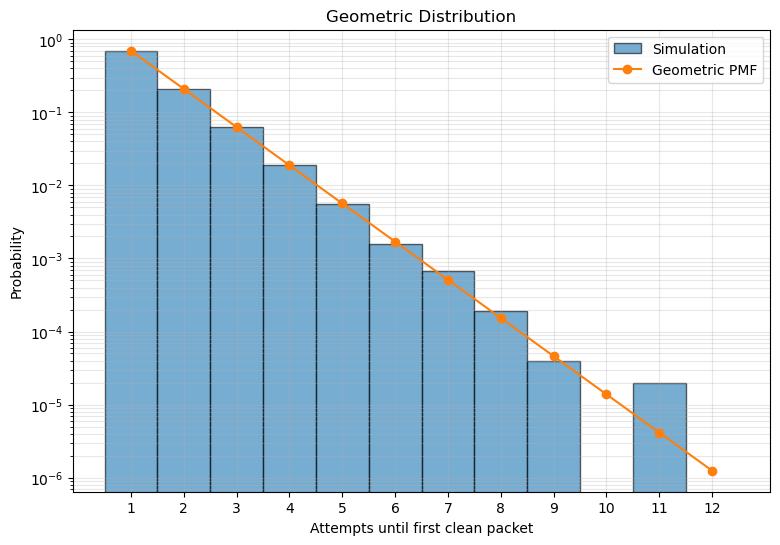


MEMORYLESS PROPERTY
-------------------

(m, n) = (1, 2)
P(N > 3 | N > 1) = 0.08966 ± 0.00164
P(N > 2) = 0.09110 ± 0.00091
Difference = -0.00144 ± 0.00188

(m, n) = (3, 2)
P(N > 5 | N > 3) = 0.09313 ± 0.00559
P(N > 2) = 0.09110 ± 0.00091
Difference = 0.00203 ± 0.00566

(m, n) = (5, 2)
P(N > 7 | N > 5) = 0.09921 ± 0.01883
P(N > 2) = 0.09110 ± 0.00091
Difference = 0.00811 ± 0.01885


In [ ]:
#STEP 6 - Retransmissions and the geometric distribution

import numpy as np
import matplotlib.pyplot as plt

print(f"The number of attempts until the first clean packet is geometrically distributed because")
print(f"each attempt is a Bernoulli trial with two outcomes: clean or not clean, and we count the")
print(f"attempts until the first clean packet. The key assumption is that packet outcomes are ")
print(f"independent across attempts and have the same clean probability q on every attempt")
print(f" ")

# Parameters
q = 0.7
num_sequences = 10**5


# Function
def attempts_until_clean(q):
    attempts = 1

    while np.random.random() > q:
        attempts += 1

    return attempts


# Simulation
samples = np.array([
    attempts_until_clean(q)
    for _ in range(num_sequences)
])


# ----------------------------------------
# Mean and variance
# ----------------------------------------

sample_mean = np.mean(samples)
sample_variance = np.var(samples, ddof=1)

theoretical_mean = 1 / q
theoretical_variance = (1 - q) / q**2

print("MEAN AND VARIANCE")
print("-----------------")
print(f"Sample mean:       {sample_mean:.5f}")
print(f"Theoretical mean:  {theoretical_mean:.5f}")
print(f"Sample variance:   {sample_variance:.5f}")
print(f"Theoretical var:   {theoretical_variance:.5f}")


# ----------------------------------------
# Histogram + geometric PMF
# ----------------------------------------

max_attempts = 12

bins = np.arange(0.5, max_attempts + 1.5, 1)

plt.figure(figsize=(9, 6))

plt.hist(
    samples,
    bins=bins,
    density=True,
    alpha=0.6,
    edgecolor='black',
    label='Simulation'
)

n = np.arange(1, max_attempts + 1)
pmf = q * (1 - q)**(n - 1)

plt.plot(
    n,
    pmf,
    'o-',
    label='Geometric PMF'
)

plt.yscale('log')
plt.xlabel('Attempts until first clean packet')
plt.ylabel('Probability')
plt.title('Geometric Distribution')
plt.xticks(n)
plt.legend()
plt.grid(True, which='both', alpha=0.3)

plt.show()


# ----------------------------------------
# Memoryless property
# ----------------------------------------

pairs = [(1, 2), (3, 2), (5, 2)]

print()
print("MEMORYLESS PROPERTY")
print("-------------------")

for m, n in pairs:

    # Conditional probability
    conditional_samples = samples[samples > m]

    p_cond = np.mean(conditional_samples > m + n)

    se_cond = np.sqrt(
        p_cond * (1 - p_cond) / len(conditional_samples)
    )

    # Unconditional probability
    p_uncond = np.mean(samples > n)

    se_uncond = np.sqrt(
        p_uncond * (1 - p_uncond) / len(samples)
    )

    difference = p_cond - p_uncond

    se_difference = np.sqrt(
        se_cond**2 + se_uncond**2
    )

    print(f"\n(m, n) = ({m}, {n})")
    print(
        f"P(N > {m+n} | N > {m}) = "
        f"{p_cond:.5f} ± {se_cond:.5f}"
    )
    print(
        f"P(N > {n}) = "
        f"{p_uncond:.5f} ± {se_uncond:.5f}"
    )
    print(
        f"Difference = "
        f"{difference:.5f} ± {se_difference:.5f}"
    )